### <center> Introduction to Python and SciML Libraries </center>

Here we will discuss the basic functionalities of Python that we use for data science and inference of dynamical systems. 

First we will touch on the syntax of Python. 

#### Variables 

In Python, variables are defined using standard assignment syntax. Python does not require that the type of the variable be specified. For example `int x = 5` is not valid Python syntax, instead the variable type is inferred at runtime. All Python types can be assigned to variables including constants and functions. Varibles can also be reassigned to a new type without incident. 

#### Functions 

Functions in Python are defined using the `def f(x):` syntax. The `def` indicates the following is a function and the variables inside the parantheses comprise the arguments. Python functions can have an arbitrary number of arguments and an arbitrary number of return values. Instead of curly braces, Python uses indentation to encapsulate the function's code.  

In [ ]:
var = 5  # Variables can be assigned a constant value.


# Defining a function with a single argument
def f(x):
    return x**2


# The builtin function print can be used to print the value of a python object.
# Here we print the return value of f
print(f(var))

var = f  # Variables can hold any type, including functions

print(var(6))  # Calling the variable as a function

25
36


In [ ]:
# Python functions can have many arguments
def f(x, y, z):
    return x**2 + y**2 + z**2


print(f(2, 2, 2))


# And many returns
def g(x, y, z):
    return x**2, y**2, z**2


var1, var2, var3 = g(
    2, 2, 2
)  # Variables can be assigned using the return values of a function

print(var1, var2, var3)

12
4 4 4


#### Loops

Python's loop syntax is similar to other C Style programming languages. The simplest loop uses `range(x)` with an integer argument `x`. The indented code block repeats `x` times. The variable `i` can be used to access the value of the counter. Note that in Python the loop counter starts at zero. Other Python objects can be looped over, but for now we will stick with `range`.

In [ ]:
for i in range(10):
    print(i)

0
1
2
3
4
5
6
7
8
9


#### Lists and NumPy Arrays

Python implements an object called a list which can hold many values at once. Lists are useful for holding values computed in loops. To add a new value `x` to the end of a list we use the syntax `L.append(x)`. To select a value at a specific index of the list we use the syntax `L[i]` and to determine the length of the list we call `len(L)`. 

In [ ]:
L = []  # Initializing an empty list
L = [5, 6, 3]  # A list can be initialized with values
L = list()  # Alternative way to initialize an empty list

for i in range(10):
    L.append(i**2)

print(L)

print(L[2])

print(len(L))

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
4
10


We will however immediately turn away from Python lists because a Python package called NumPy implements a superior array object which offers speed improvements in computation and increased flexibility. Importing NumPy into our project is as simple as adding a statement at the top of our code cell `import numpy as np`. This adds NumPy to the project and makes it's functions callable via the variable `np`. 

We will first discuss the NumPy array object. This is similar to the Python list with the same selection syntax. NumPy arrays have a property called shape that can be called using `arr.shape`. This tells us the shape of the array and can be viewed as an extension of the `len()` function for lists. Note the value of `.shape` is not a integer but rather a tuple (immutable list). This is because NumPy arrays can be multi-dimensional, which is their first great advantage over lists. 

We can access elements in multidimensional NumPy arrays using `arr[x,y]`, for example if `arr` is a 2x2 matrix. If `arr` is 1-dimensional the selection syntax is the same as the Python list. 

In [ ]:
import numpy as np

arr = np.array([1, 2, 3])  # We create the array by
# makicalling np.array on a python list.

print(arr)

print(arr.shape)

multi_dim_arr = np.zeros((3, 3))  # np.zeros creates an array of zeros,
# the argument (3,3) tells numpy to create a 3x3 array of zeros.

print(multi_dim_arr)

multi_dim_arr = np.array([[2, 2], [2, 2]])  # You can also create numpy arrays by hand
# using lists of lists, this creates a 2x2 array

print(multi_dim_arr.shape)
print(multi_dim_arr)

[1 2 3]
(3,)
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
(2, 2)
[[2 2]
 [2 2]]


NumPy is extremely flexible and has numerous functions for creating and manipulating arrays. For example, we can operate on entire arrays at once to speed up computation. Various operations on arrays can be computed including means, standard deviations, and exponents. 

In [6]:
arr = np.array([1, 2, 3])  # We create the array by calling np.array on a python list.

print(arr)
print(arr.shape)

print(np.sum(arr))


[1 2 3]
(3,)
6


For 1-dimensional arrays this process is simple, however for higher dimensional arrays things become a bit more tricky. Consider a 2 dimensional array 

$$
\begin{bmatrix} a & b \\ c & d \end{bmatrix}. 
$$

How do we take the sum of this matrix? We have 3 clear options, the sum of the rows, the sum of the columns, or the sum of all elements. NumPy can easily handle all of these cases but it is important to take care our operation is doing what we expect.

In [ ]:
arr = np.array([[1, 2], [3, 4]])

print(arr.shape, "\n")

arr_row_sum = np.sum(arr, axis=0)  # Sum of the rows
print(arr_row_sum)
print(arr_row_sum.shape, "\n")

arr_col_sum = np.sum(arr, axis=1)  # Sum of the columns
print(arr_col_sum)
print(arr_col_sum.shape, "\n")

arr_sum = np.sum(arr)  # Sum of the elements
print(arr_sum)
print(arr_sum.shape)

(2, 2) 

[4 6]
(2,) 

[3 7]
(2,) 

10
()


#### Multiplication in NumPy

Performing multiplication of arrays is another nontrival operation. There are many ways to perform array multiplication and we will demonstrate a few below.

In [ ]:
arr = np.array([[1, 2], [3, 4]])

print(arr.shape, "\n")

# Multiplication by scalar
print(2 * arr, "\n")
arr_2 = np.array([[1, 2], [3, 4]])

# Element wise multiplication
print(arr * arr_2, "\n")

# Matrix multiplication
print(arr @ arr_2, "\n")  
# Note that matrix multiplication uses the @ operator

(2, 2) 

[[2 4]
 [6 8]] 

[[ 1  4]
 [ 9 16]] 

[[ 7 10]
 [15 22]] 



#### Other useful NumPy Functions

We will briefly mention some other useful functions in NumPy. 

`np.arange(start,stop,step)` creates an array of values between start and stop with spacing step. 

In [ ]:
delta_t = 0.1
ts = np.arange(0, 10 + delta_t, delta_t)

print(ts)

[ 0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3
  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7
  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1
  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5
  5.6  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9
  7.   7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3
  8.4  8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7
  9.8  9.9 10. ]


`np.reshape(arr,shape)` transform a NumPy array into a new shape. This can be useful for matrix multiplication. This can also be called using `arr.reshape(shape). ` 

In [ ]:
arr = np.array([[1, 2], [3, 4]])
print(arr, "\n")
print(arr.shape, "\n")

arr = np.reshape(arr, (4,))  # Transforms arr into a flat array
print(arr, "\n")
print(arr.shape, "\n")

[[1 2]
 [3 4]] 

(2, 2) 

[1 2 3 4] 

(4,) 



`np.transpose(arr)` swaps the rows and columns of a matrix. This can also be called using `arr.T`. 

In [11]:
arr = np.array([[1, 2], [3, 4], [5, 6]])
print(arr, "\n")
print(arr.shape, "\n")

arr = np.transpose(arr)  # Transposes the array
print(arr, "\n")
print(arr.shape, "\n")

[[1 2]
 [3 4]
 [5 6]] 

(3, 2) 

[[1 3 5]
 [2 4 6]] 

(2, 3) 



NumPy also implements various mathematical functions that operate over the entire array. For example, `np.exp` and `np.log`. These operations are applied element-wise to the array.  

In [12]:
arr = np.array([[1, 2], [3, 4], [5, 6]])
print(arr, "\n")
print(arr.shape, "\n")

print(np.exp(arr))

[[1 2]
 [3 4]
 [5 6]] 

(3, 2) 

[[  2.71828183   7.3890561 ]
 [ 20.08553692  54.59815003]
 [148.4131591  403.42879349]]


#### Matplotlib

Matplotlib is another extremely useful Python package for plotting. This package allows us to visualize the results of various mathematical computations performed in NumPy. We import Matplotlib the same way as NumPy.

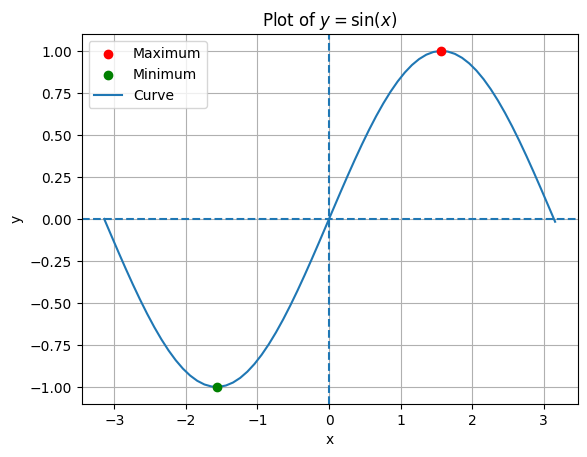

In [ ]:
import matplotlib.pyplot as plt

# Generate the data for our plot
step = 0.1
xs = np.arange(-np.pi, np.pi + step, step)
ys = np.sin(xs)

plt.title("Plot of $y=\\sin(x)$")

# Matplotlib can plot points using the scatter function
plt.scatter(np.pi / 2, 1.0, label="Maximum", color="red", zorder=10)
plt.scatter(
    -np.pi / 2, -1.0, label="Minimum", color="green", zorder=10
)  # Zorder makes sure the dot is plotted on top of the line

# Matplotlib will interpolate a 
# continuous curve from the points if you use plot
plt.plot(xs, ys, label="Curve")

# Plotting horizontal and vertical lines
plt.axhline(y=0, linestyle="dashed")
plt.axvline(x=0, linestyle="dashed")

# Adding labels to our plot
plt.xlabel("x")
plt.ylabel("y")

# Adding a grid background
plt.grid()

# Adding the legend, this uses the label string 
# in scatter and plot to populate the legend
plt.legend()

# Shows the plot on the screen
plt.show()

Matplotlib has a variety of features for creating high quality visuals, the above example only covers the basics but these are sufficient for our plotting purposes. 